<a href="https://colab.research.google.com/github/kanny789/ddo-data-dev/blob/main/Credit_Card_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql.functions import col, count, sum, window, expr, floor
from pyspark.sql.functions import explode_outer
from pyspark.sql.functions import col, log1p
from pyspark.sql.window import Window
from pyspark.sql.functions import log1p
from pyspark.sql.functions import sum as _sum, count


In [ ]:
%pip install kagglehub[pandas-datasets] # DBTITLE 1,Load the dataset

In [ ]:
# Load the latest version
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_6785/4245861505.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [ ]:
import pandas as pd
import numpy as np

# Drop duplicates
df = df.drop_duplicates()

# Cast columns
df["Time"] = df["Time"].astype(float)
df["Amount"] = df["Amount"].astype(float)
df["Class"] = df["Class"].astype(int)

for i in range(1, 29):
    df[f"V{i}"] = df[f"V{i}"].astype(float)

silver_clean = df.copy()


In [ ]:
silver_clean["HourOfDay"] = np.floor(silver_clean["Time"] / 3600) % 24
silver_clean["HourOfDay"] = silver_clean["HourOfDay"].astype(int)

silver_clean["IsNight"] = ((silver_clean["HourOfDay"] < 6) |
                           (silver_clean["HourOfDay"] > 22)).astype(int)

silver_time = silver_clean.copy()

In [ ]:
silver_clean["Amount_log"] = np.log1p(silver_clean["Amount"])
silver_amount =silver_clean.copy()
print(silver_amount)


            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V24       V25  \
0       0.462388  0.239599  0.098698  0.363787  ...  0.06692

In [ ]:


# Ensure data is sorted by Time (Spark Window.orderBy)
silver_amount = silver_amount.sort_values("Time").reset_index(drop=True)

# Previous Time
silver_amount["PrevTime"] = silver_amount["Time"].shift(1)

# Time since previous
silver_amount["TimeSincePrev"] = silver_amount["Time"] - silver_amount["PrevTime"]

# Previous Amount
silver_amount["PrevAmount"] = silver_amount["Amount"].shift(1)

# Amount difference
silver_amount["AmountDiff"] = (silver_amount["Amount"] - silver_amount["PrevAmount"]).round(2)

# Amount ratio (safe divide)
silver_amount["AmountRatio"] = (silver_amount["Amount"] / silver_amount["PrevAmount"]).replace([np.inf, -np.inf], np.nan).round(2)

print(silver_amount)





            Time         V1         V2        V3        V4        V5  \
0            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
1            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
2            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
3            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
4            2.0  -0.425966   0.960523  1.141109 -0.168252  0.420987   
...          ...        ...        ...       ...       ...       ...   
283721  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
283722  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
283723  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
283724  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
283725  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...  Amount  Class  HourOfDay  \
0      -0.082361 -0.078803  0.085102 -0.255425  ...   

In [ ]:
# Define feature columns
feature_cols = [f"V{i}" for i in range(1, 29)] + [
    "Amount_log", "HourOfDay", "IsNight",
    "TimeSincePrev", "AmountDiff", "AmountRatio"
]

# Select only the relevant columns (Class + features)
df_sel = silver_amount[["Class"] + feature_cols]

# Drop rows with NaN in any of the feature columns
df_sel = df_sel.dropna(subset=feature_cols)

# Count rows
print("Rows:", len(df_sel))

Rows: 281917


In [ ]:
# Optional: keep labels separately
# Separate labels
y = df_sel.pop("Class").astype(int)
print("Rows:",len(y))

# Impute missing numeric values with median
df_sel = df_sel.fillna(df_sel.median())

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df_sel.values)

Rows: 281917


In [ ]:
# If labels exist, keep only non-fraud for training
if y.sum() > 0:
    X_train = X[y == 0]  # train on normal only
else:
    X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

# Create a small validation set (mix of normal + anomalies if labels exist)
X_val = X[:int(0.2 * len(X))]  # simple

In [ ]:
import builtins
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]
encoding_dim = builtins.max(8, input_dim // 3)

inp = layers.Input(shape=(input_dim,))
x = layers.Dense(encoding_dim*2, activation="relu")(inp)
x = layers.Dense(encoding_dim, activation="relu")(x)
x = layers.Dense(encoding_dim*2, activation="relu")(x)
out = layers.Dense(input_dim, activation="linear")(x)

autoencoder = models.Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 22)             │           770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           253 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │           782 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,069 (8.08 KB)

 Trainable params: 2,069 (8.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
)

Epoch 1/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.6593 - val_loss: 0.5904
Epoch 2/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4879 - val_loss: 0.5339
Epoch 3/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4367 - val_loss: 0.5103
Epoch 4/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4111 - val_loss: 0.4886
Epoch 5/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3937 - val_loss: 0.4777
Epoch 6/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3822 - val_loss: 0.4733
Epoch 7/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3745 - val_loss: 0.4665
Epoch 8/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3682 - val_loss: 0.4579
Epoch 9/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3640 - val_loss: 0.4582
Epoch 10/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3614 - val_loss: 0.4566
Epoch 11/50
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3594 - val_loss: 0.4526
Epoch 12/50
1100/1100 ━━━━━━━━

In [ ]:
import numpy as np
recon = autoencoder.predict(X)
mse = np.mean(np.square(X - recon), axis=1)

# Choose threshold: e.g., 99.5th percentile
threshold = np.percentile(mse, 83.61)
anomaly_flags = mse > threshold

# If labels exist, evaluate
from sklearn.metrics import precision_recall_curve, auc
if y.sum() > 0:
    precision, recall, _ = precision_recall_curve(y, mse)
    auprc = auc(recall, precision)
    print("AUPRC:", auprc)

8810/8810 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
AUPRC: 0.44821454666327515


In [ ]:
!pip install mlflow
import mlflow
import mlflow.keras
import joblib
import os

# Set experiment (in Colab this just creates a local tracking dir unless you connect to a remote MLflow server)
mlflow.set_experiment("autoencoder_fraud")

with mlflow.start_run():

    # Log encoding dimension safely
    mlflow.log_param("encoding_dim", int(encoding_dim) if encoding_dim is not None else None)

    # Log model
    mlflow.keras.log_model(autoencoder, "autoencoder_model")

    from google.colab import drive
    drive.mount('/content/drive')
    # Save scaler locally in Colab
    scaler_path = "/content/drive/MyDrive/scaler.joblib"
    joblib.dump(scaler, scaler_path)

    # Log artifact from local path
    mlflow.log_artifact(scaler_path)

    # Safe AUPRC logging
    try:
        mlflow.log_metric("auprc", float(auprc))
    except:
        mlflow.log_metric("auprc", -1.0)


2026/03/14 05:49:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 05:49:25 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Mounted at /content/drive


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, errors)

f1_scores = 2 * precision * recall / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_threshold)

Best threshold: 113.1459110727128


/tmp/ipykernel_6785/2881374244.py:6: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * precision * recall / (precision + recall)


In [ ]:
print(errors.min(), errors.max())

0.024481196316592353 113.1459110727128


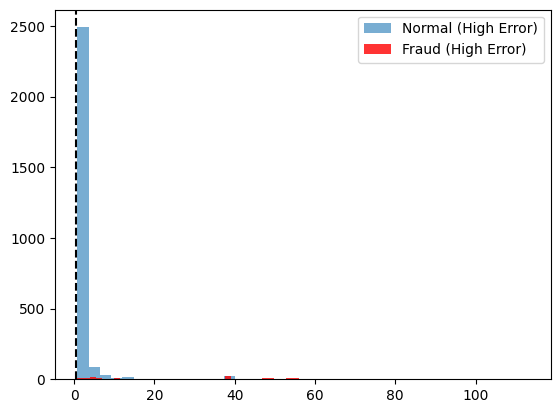

In [ ]:
cut = np.percentile(errors, 95)
mask = errors > cut

plt.hist(errors[mask & (y_val==0)], bins=40, alpha=0.6, label="Normal (High Error)")
plt.hist(errors[mask & (y_val==1)], bins=40, alpha=0.8, label="Fraud (High Error)", color="red")
plt.axvline(threshold, color='black', linestyle='--')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Model

# layer index 2 = Dense(encoding_dim)
encoder = Model(inputs=autoencoder.input,
                outputs=autoencoder.layers[2].output)

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 22)             │           770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           253 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │           782 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,209 (24.26 KB)

 Trainable params: 2,069 (8.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,140 (16.18 KB)

In [ ]:
Z = encoder.predict(X_val)

1762/1762 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [ ]:
!pip install umap-learn
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
Z_2d = reducer.fit_transform(Z)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


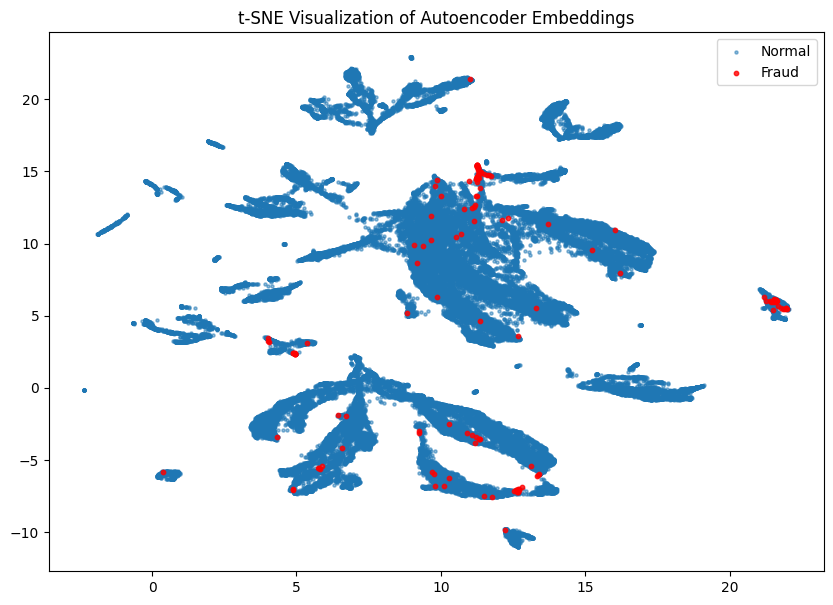

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(Z_2d[y_val == 0, 0], Z_2d[y_val == 0, 1],
            s=5, alpha=0.5, label="Normal")
plt.scatter(Z_2d[y_val == 1, 0], Z_2d[y_val == 1, 1],
            s=10, alpha=0.8, label="Fraud", color="red")

plt.legend()
plt.title("t-SNE Visualization of Autoencoder Embeddings")
plt.show()

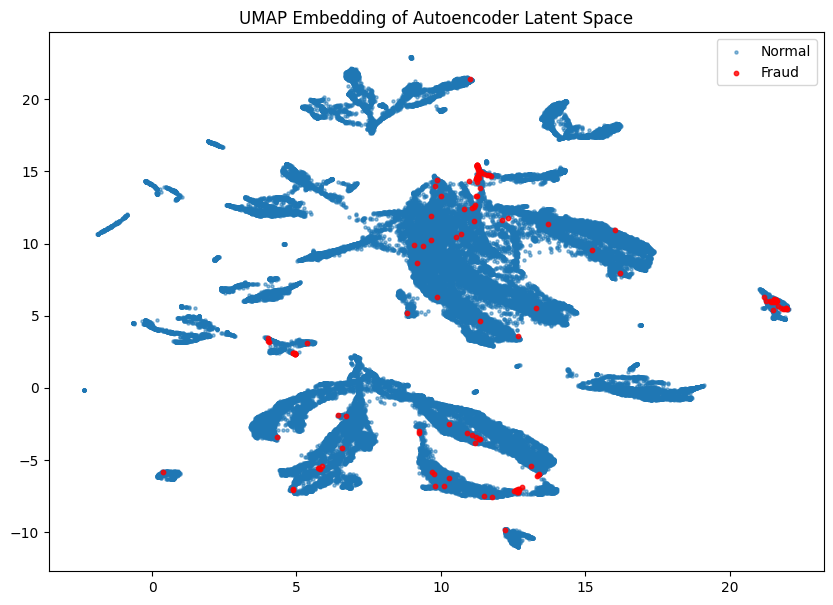

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(Z_2d[y_val==0,0], Z_2d[y_val==0,1], s=5, alpha=0.5, label="Normal")
plt.scatter(Z_2d[y_val==1,0], Z_2d[y_val==1,1], s=10, alpha=0.8, color="red", label="Fraud")
plt.legend()
plt.title("UMAP Embedding of Autoencoder Latent Space")
plt.show()

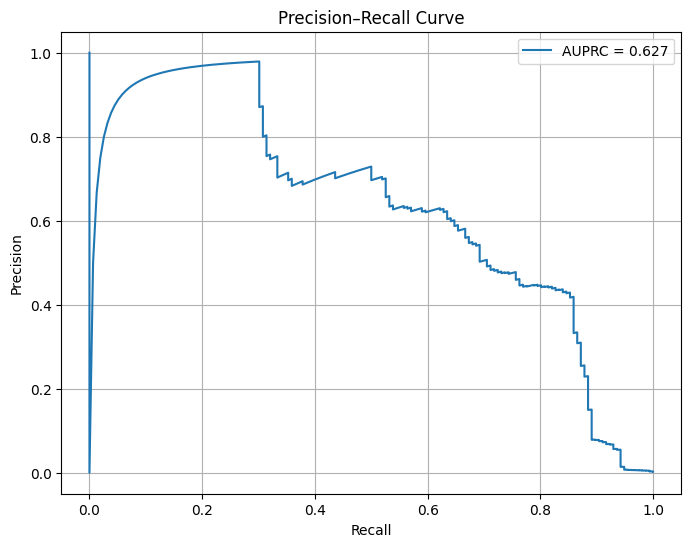

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, errors)
auprc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

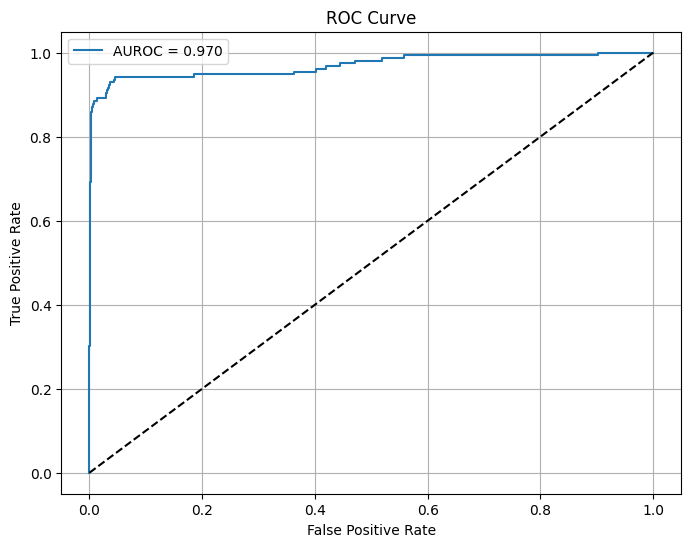

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_val, errors)
auroc = roc_auc_score(y_val, errors)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

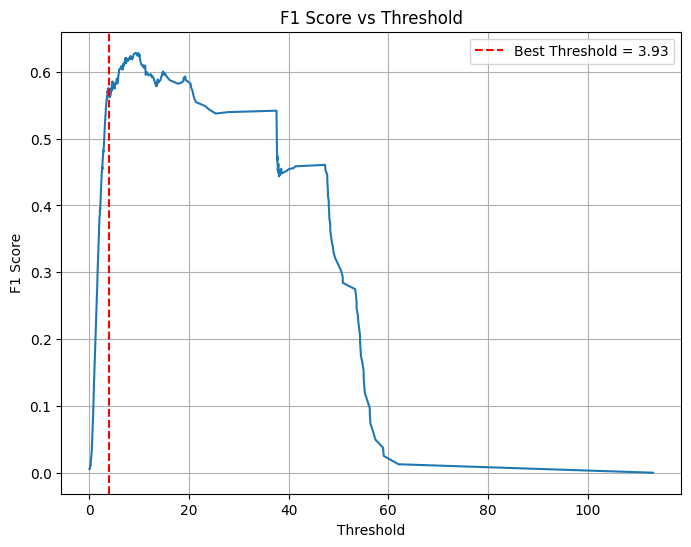

In [ ]:
import numpy as np

f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores[:-1])
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

#Testing

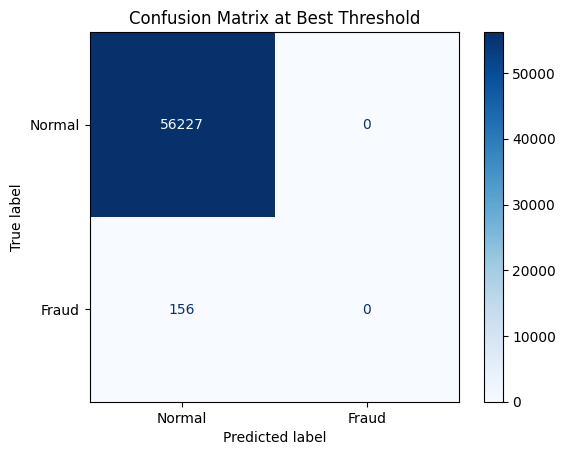

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = (errors > best_threshold).astype(int)
cm = confusion_matrix(y_val, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix at Best Threshold")
plt.show()

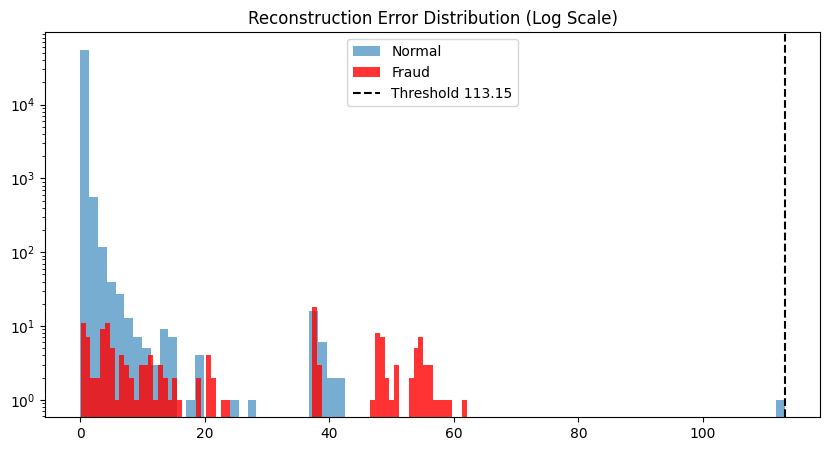

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(errors[y_val == 0], bins=80, alpha=0.6, label="Normal")
plt.hist(errors[y_val == 1], bins=80, alpha=0.8, label="Fraud", color="red")
plt.axvline(best_threshold, color='black', linestyle='--', label=f"Threshold {best_threshold:.2f}")
plt.yscale("log")
plt.legend()
plt.title("Reconstruction Error Distribution (Log Scale)")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve, confusion_matrix

# PR metrics
precision, recall, thresholds = precision_recall_curve(y_val, errors)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

# Predictions
preds = (errors > best_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

# AUROC
auroc = roc_auc_score(y_val, errors)

# AUPRC
from sklearn.metrics import auc
auprc = auc(recall, precision)

print("AUPRC:", auprc)
print("AUROC:", auroc)
print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])
print("TP, FP, TN, FN:", tp, fp, tn, fn)
print("Error range:", errors.min(), errors.max())

AUPRC: 0.6266896006540338
AUROC: 0.969897092965192
Best threshold: 9.348921637964562
Precision: 0.6226415094339622
Recall: 0.6346153846153846
F1: 0.6285714280714737
TP, FP, TN, FN: 98 60 56167 58
Error range: 0.024481196316592353 113.1459110727128


**# %Hybrid Scoring**

In [ ]:
Z = encoder.predict(X_val)
mu = Z[y_val == 0].mean(axis=0)
latent_dist = np.linalg.norm(Z - mu, axis=1)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
E_norm = scaler.fit_transform(errors.reshape(-1,1)).flatten()
D_norm = scaler.fit_transform(latent_dist.reshape(-1,1)).flatten()
alpha = 0.5  # equal weighting
hybrid_score = alpha * E_norm + (1 - alpha) * D_norm






1762/1762 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


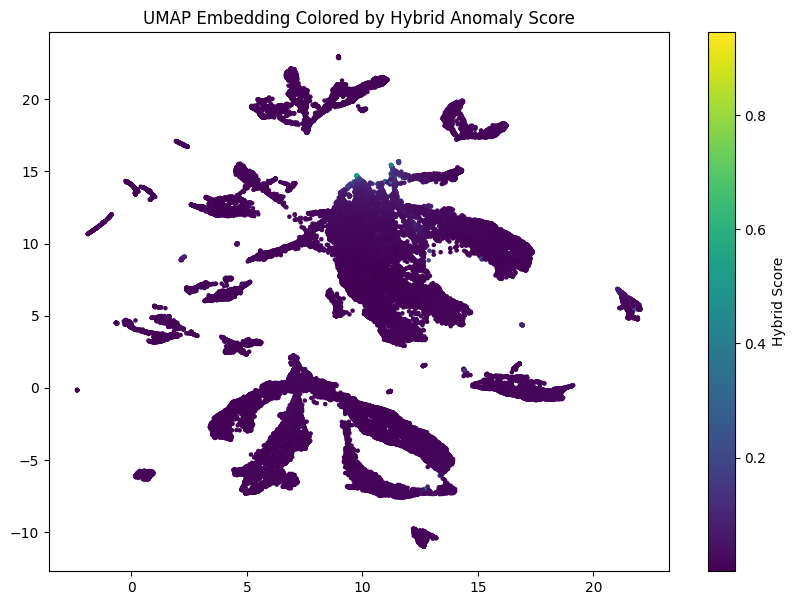

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# PR for reconstruction error
prec_e, rec_e, _ = precision_recall_curve(y_val, errors)
auprc_e = auc(rec_e, prec_e)

# PR for hybrid score
prec_h, rec_h, _ = precision_recall_curve(y_val, hybrid_score)
auprc_h = auc(rec_h, prec_h)

import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
Z_2d = reducer.fit_transform(Z)

plt.figure(figsize=(10,7))
plt.scatter(Z_2d[:,0], Z_2d[:,1], c=hybrid_score, cmap="viridis", s=5)
plt.colorbar(label="Hybrid Score")
plt.title("UMAP Embedding Colored by Hybrid Anomaly Score")
plt.show()